# MAE SSL vs. Supervised Multitask-LoRA Baselines — OOD Generalization Comparison

Compares your pretrained MAE (best layer/protocol per split, from real result JSONs) against the
Table 12 supervised multitask-LoRA baselines (transformer / patchtst / timesformer1d) on HAR
cross-device / cross-env / cross-user splits.

**Design decisions locked in per our discussion:**
1. Compare against your **previous MAE run(s)** — both with and without `exclude_devices=AmazonPlug`
   are loaded below so you can see both side by side and decide which is the fair comparison.
2. **Best layer per split** — for each split, we scan every (protocol, layer) combination at the
   final checkpoint and take the max-accuracy one. This is printed out explicitly (not hidden)
   so you can sanity-check it before it goes in the figure.
3. **F1 included** — pulled from the same JSON (`{protocol}_f1` keys) alongside accuracy.

No figure numbering yet — title is left generic so it's easy to renumber/reposition later.

**Before running:** point `RESULTS_DIR` at your real results directory and confirm the two filter
dicts below (`FILTERS_WITH_AMAZONPLUG`, `FILTERS_EXCL_AMAZONPLUG`) actually match your files —
run with `DEBUG=True` first if either returns 0 matches.


In [1]:

import json
import re
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 130,
})

# -- Paths ----------------------------------------------------------------
RESULTS_DIR = Path("/home/zhuzih19/csi-project/csi-fall-detection/results/mae_har")  # TODO: confirm
FIG_DIR = Path("/home/zhuzih19/csi-project/csi-fall-detection/figs")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TEST_SPLITS = ["test_cross_device", "test_cross_env", "test_cross_user"]  # ID intentionally excluded -- this comparison is OOD-only
SPLIT_LABELS = {
    "test_cross_device": "Cross-Device",
    "test_cross_env": "Cross-Env\n(different environment)",
    "test_cross_user": "Cross-User",
}
PROTOCOLS = ["knn", "lp", "mlp"]  # extend with "attn_light"/"attn_heavy" if your JSON has them


In [2]:

def load_matching_results(directory, filters, debug=False):
    # Recursively load all *.json result files under `directory` whose `args` dict matches
    # every key/value in `filters`. A filter value of None means 'no constraint on that key'.
    # With debug=True, prints a [match]/[skip reason] line per candidate file.
    results = []
    candidates = sorted(Path(directory).rglob("*.json"))
    if debug:
        print(f"[debug] found {len(candidates)} .json files under {directory} (recursive)")

    for fp in candidates:
        try:
            data = json.loads(fp.read_text())
        except (json.JSONDecodeError, UnicodeDecodeError) as e:
            if debug:
                print(f"[skip] {fp.name}: failed to parse ({e})")
            continue

        args = data.get("args")
        if args is None:
            if debug:
                print(f"[skip] {fp.name}: no args key")
            continue

        reasons = []
        for key, expected in filters.items():
            if expected is None:
                continue
            actual = args.get(key)
            if actual is None:
                reasons.append(f"{key} missing from args")
                continue
            try:
                if isinstance(expected, float):
                    if not np.isclose(float(actual), expected):
                        reasons.append(f"{key}={actual!r} != {expected}")
                elif isinstance(expected, int):
                    if int(actual) != expected:
                        reasons.append(f"{key}={actual!r} != {expected}")
                else:
                    if str(actual) != str(expected):
                        reasons.append(f"{key}={actual!r} != {expected!r}")
            except (TypeError, ValueError):
                reasons.append(f"{key}={actual!r} not comparable to {expected!r}")

        if reasons:
            if debug:
                print(f"[skip] {fp.name}: " + "; ".join(reasons))
            continue

        if debug:
            print(f"[match] {fp.name}")
        results.append(data)
    return results


def get_layers(result):
    first_ckpt = next(iter(result["evals"].values()))
    layers = list(first_ckpt.keys())
    layers.sort(key=lambda x: int(re.search(r"\d+", x).group()))
    return layers


def get_checkpoints(result):
    ckpts = list(result["evals"].keys())
    ckpts.sort(key=lambda x: int(re.search(r"\d+", x).group()))
    return ckpts


def best_layer_per_split(result, protocols=PROTOCOLS, splits=TEST_SPLITS, checkpoint=None):
    # For each split, scan every (protocol, layer) combo at `checkpoint` (default: final)
    # and return the max-accuracy one, along with its matching F1 if present.
    # Returns {split: {"protocol": p, "layer": layer_name, "acc": v, "f1": v_or_None}}.
    ckpts = get_checkpoints(result)
    checkpoint = checkpoint or ckpts[-1]
    layers = get_layers(result)

    out = {}
    for split in splits:
        best = None
        for layer in layers:
            layer_evals = result["evals"][checkpoint][layer][split]
            for p in protocols:
                acc = layer_evals.get(f"{p}_acc")
                if acc is None:
                    continue
                if best is None or acc > best["acc"]:
                    f1 = layer_evals.get(f"{p}_f1")
                    best = {"protocol": p, "layer": layer, "acc": acc, "f1": f1}
        out[split] = best
    return out


## Load your MAE runs (with and without AmazonPlug excluded)

Adjust these two filter dicts if your real `args` keys differ — set `DEBUG=True` and re-run to see
per-file skip reasons. The `exclude_devices` key name/format is a guess based on your log line
(`[exclude-devices] dropping device='AmazonPlug'`) — confirm/fix it once you see real `args` dumps.


In [3]:

DEBUG = False  # flip to True if either filter below returns 0 matches

FILTERS_WITH_AMAZONPLUG = {
    "mask_ratio": 0.75,
    "mask_strategy": "random",
    "patch_h": 29,
    "patch_w": 25,
    "encoder_depth": 12,
    "seed": 42,
    "exclude_devices": None,  # TODO: set to the real "no exclusion" value once confirmed (e.g. "" or [])
}

FILTERS_EXCL_AMAZONPLUG = {
    "mask_ratio": 0.75,
    "mask_strategy": "random",
    "patch_h": 29,
    "patch_w": 25,
    "encoder_depth": 12,
    "seed": 42,
    "exclude_devices": None,  # TODO: set to e.g. "AmazonPlug" or ["AmazonPlug"] once confirmed
}

runs_with = load_matching_results(RESULTS_DIR, FILTERS_WITH_AMAZONPLUG, debug=DEBUG)
runs_excl = load_matching_results(RESULTS_DIR, FILTERS_EXCL_AMAZONPLUG, debug=DEBUG)

print(f"With-AmazonPlug matches: {len(runs_with)}")
print(f"Excl-AmazonPlug matches: {len(runs_excl)}")

if not runs_with:
    print("[!] 0 matches for FILTERS_WITH_AMAZONPLUG -- set DEBUG=True above and re-run, "
          "or this run may not exist yet (only the excl-AmazonPlug log has been shared so far).")
if not runs_excl:
    print("[!] 0 matches for FILTERS_EXCL_AMAZONPLUG -- set DEBUG=True above and re-run.")


With-AmazonPlug matches: 2
Excl-AmazonPlug matches: 2


## Compute best-layer-per-split for each available MAE run

Prints the exact (protocol, layer, acc, f1) chosen for every split, for every run found, so you
can eyeball it before anything goes into the comparison table/figure below.


In [4]:

mae_variants = {}  # label -> {split: {...}}

for label, runs in [("MAE (with AmazonPlug)", runs_with), ("MAE (excl. AmazonPlug)", runs_excl)]:
    if not runs:
        continue
    if len(runs) > 1:
        print(f"[warn] {len(runs)} files matched for '{label}' -- using the first one "
              f"(narrow the filter, e.g. add exact seed/exp name, if this isn't the right file).")
    result = runs[0]
    best = best_layer_per_split(result)
    mae_variants[label] = best

    print(f"\n=== {label} ({result.get('exp', '?')}) ===")
    for split in TEST_SPLITS:
        b = best[split]
        if b is None:
            print(f"  {SPLIT_LABELS[split]:<30} no data")
        else:
            f1_str = f"{b['f1']:.3f}" if b["f1"] is not None else "N/A"
            print(f"  {SPLIT_LABELS[split]:<30} best={b['protocol'].upper():<5} "
                  f"layer={b['layer']:<10} acc={b['acc']:.3f}  f1={f1_str}")

if not mae_variants:
    print("\nNo MAE runs loaded yet -- fix the filters above before continuing.")


[warn] 2 files matched for 'MAE (with AmazonPlug)' -- using the first one (narrow the filter, e.g. add exact seed/exp name, if this isn't the right file).

=== MAE (with AmazonPlug) (mae_har_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128) ===
  Cross-Device                   best=LP    layer=layer_1    acc=0.523  f1=0.399
  Cross-Env
(different environment) best=LP    layer=layer_9    acc=0.523  f1=0.401
  Cross-User                     best=LP    layer=layer_1    acc=0.497  f1=0.376
[warn] 2 files matched for 'MAE (excl. AmazonPlug)' -- using the first one (narrow the filter, e.g. add exact seed/exp name, if this isn't the right file).

=== MAE (excl. AmazonPlug) (mae_har_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128) ===
  Cross-Device                   best=LP    layer=layer_1    acc=0.523  f1=0.399
  Cross-Env
(different environment) best=LP    layer=layer_9    acc=0.523  f1=0.401
  Cross-User                     best=LP    layer=layer_1    acc=

## Table 12 baseline (supervised multitask-LoRA, hardcoded from the paper)

Mean ± std as reported. F1 for `test_id` is not applicable here since this comparison is OOD-only.


In [5]:

# Values transcribed directly from the Table 12 you pasted -- double check against the source
# table if you spot a transcription error.
TABLE12_BASELINE = {
    "transformer": {
        "test_cross_device": {"acc": (0.3514, 0.0411), "f1": (0.2645, 0.0277)},
        "test_cross_env":    {"acc": (0.3709, 0.0460), "f1": (0.4007, 0.0379)},
        "test_cross_user":   {"acc": (0.4874, 0.0045), "f1": (0.2967, 0.0294)},
    },
    "patchtst": {
        "test_cross_device": {"acc": (0.3458, 0.0210), "f1": (0.2295, 0.0223)},
        "test_cross_env":    {"acc": (0.3584, 0.0557), "f1": (0.3430, 0.0553)},
        "test_cross_user":   {"acc": (0.4858, 0.0125), "f1": (0.2706, 0.0801)},
    },
    "timesformer1d": {
        "test_cross_device": {"acc": (0.4209, 0.0321), "f1": (0.2769, 0.0387)},
        "test_cross_env":    {"acc": (0.3920, 0.0147), "f1": (0.3183, 0.1026)},
        "test_cross_user":   {"acc": (0.5077, 0.0168), "f1": (0.2688, 0.0774)},
    },
}
BASELINE_LABELS = {"transformer": "Transformer", "patchtst": "PatchTST", "timesformer1d": "TimesFormer-1D"}


## Build the comparison table

Combines the Table 12 baselines with whichever MAE variant(s) loaded successfully above. This
prints as a plain table first — review it before the plotting cell runs.


In [6]:

rows = []
for model_key, per_split in TABLE12_BASELINE.items():
    for split in TEST_SPLITS:
        acc_mean, acc_std = per_split[split]["acc"]
        f1_mean, f1_std = per_split[split]["f1"]
        rows.append(dict(model=BASELINE_LABELS[model_key], split=split,
                          acc_mean=acc_mean * 100, acc_std=acc_std * 100,
                          f1_mean=f1_mean * 100, f1_std=f1_std * 100,
                          layer="-", protocol="-", n_seeds=None))  # n unknown from the pasted table

for label, best in mae_variants.items():
    for split in TEST_SPLITS:
        b = best[split]
        if b is None:
            continue
        f1_val = b["f1"]
        if f1_val is not None and f1_val <= 1.0:
            # Guard against scale mismatch: Table 12 F1 is on a 0-100 scale (e.g. 26.45).
            # If your JSON's f1 is stored as 0-1 (e.g. 0.2645), normalize it here so the
            # bars are actually comparable. If your JSON already stores 0-100, this branch
            # won't trigger (values > 1) and nothing changes.
            f1_val = f1_val * 100
        rows.append(dict(model=label, split=split,
                          acc_mean=b["acc"], acc_std=0.0,   # single seed -> no std
                          f1_mean=(f1_val if f1_val is not None else np.nan), f1_std=0.0,
                          layer=b["layer"], protocol=b["protocol"], n_seeds=1))

comparison_df = pd.DataFrame(rows)
print("[check] MAE f1 values normalized to 0-100 scale if they came in as 0-1 -- "
      "verify against a raw JSON value that this assumption is correct for your files.")
with pd.option_context("display.max_rows", None, "display.width", 140):
    print(comparison_df.to_string(index=False))


[check] MAE f1 values normalized to 0-100 scale if they came in as 0-1 -- verify against a raw JSON value that this assumption is correct for your files.
                 model             split  acc_mean  acc_std   f1_mean  f1_std   layer protocol  n_seeds
           Transformer test_cross_device 35.140000     4.11 26.450000    2.77       -        -      NaN
           Transformer    test_cross_env 37.090000     4.60 40.070000    3.79       -        -      NaN
           Transformer   test_cross_user 48.740000     0.45 29.670000    2.94       -        -      NaN
              PatchTST test_cross_device 34.580000     2.10 22.950000    2.23       -        -      NaN
              PatchTST    test_cross_env 35.840000     5.57 34.300000    5.53       -        -      NaN
              PatchTST   test_cross_user 48.580000     1.25 27.060000    8.01       -        -      NaN
        TimesFormer-1D test_cross_device 42.090000     3.21 27.690000    3.87       -        -      NaN
        TimesF

## Plot: Accuracy + F1, OOD splits, MAE vs. supervised baselines

- `test_cross_env` ("different environment") is highlighted since that's the target claim.
- Baseline bars get error bars from the paper's reported std; MAE bars do not (n=1 — labeled as such).
- Caveats are printed as figure footnotes rather than buried in code: dataset alignment
  (with/without AmazonPlug) and per-split best-layer selection are both stated explicitly.


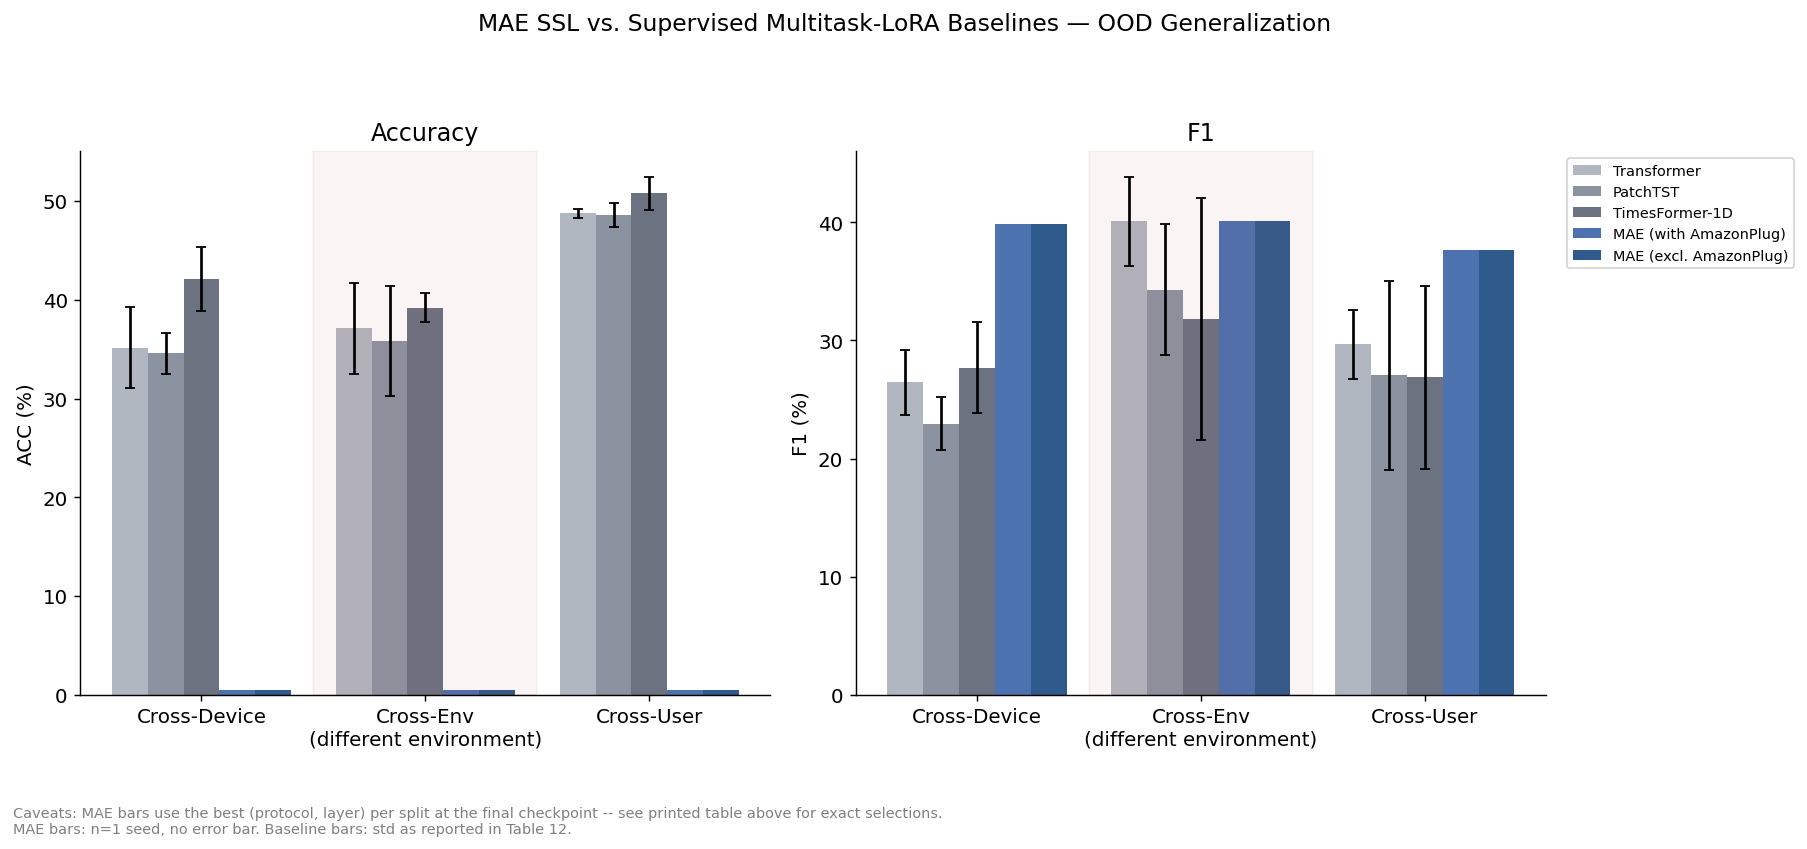

In [7]:

if not mae_variants:
    print("Skipping plot -- no MAE runs loaded. Fix the filters above first.")
else:
    model_order = ["Transformer", "PatchTST", "TimesFormer-1D"] + list(mae_variants.keys())
    model_colors = {
        "Transformer": "#B0B7C0", "PatchTST": "#8C93A0", "TimesFormer-1D": "#6B7280",
        "MAE (with AmazonPlug)": "#4C72B0", "MAE (excl. AmazonPlug)": "#2E5A8C",
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    for ax, metric in zip(axes, ["acc", "f1"]):
        x = np.arange(len(TEST_SPLITS))
        width = 0.8 / len(model_order)
        for i, model in enumerate(model_order):
            means, stds = [], []
            for split in TEST_SPLITS:
                row = comparison_df[(comparison_df.model == model) & (comparison_df.split == split)]
                if row.empty or pd.isna(row[f"{metric}_mean"].values[0]):
                    means.append(0)
                    stds.append(0)
                else:
                    means.append(row[f"{metric}_mean"].values[0])
                    stds.append(row[f"{metric}_std"].values[0])
            offset = (i - (len(model_order) - 1) / 2) * width
            yerr = stds if any(s > 0 for s in stds) else None
            ax.bar(x + offset, means, width=width, yerr=yerr, capsize=3,
                   label=model, color=model_colors.get(model))

        ax.axvspan(x[TEST_SPLITS.index("test_cross_env")] - 0.5,
                    x[TEST_SPLITS.index("test_cross_env")] + 0.5, color="#C44E52", alpha=0.06)
        ax.set_xticks(x)
        ax.set_xticklabels([SPLIT_LABELS[s] for s in TEST_SPLITS])
        ax.set_ylabel(f"{metric.upper()} (%)")
        ax.set_title("Accuracy" if metric == "acc" else "F1")

    axes[1].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")

    caveat_lines = [
        "Caveats: MAE bars use the best (protocol, layer) per split at the final checkpoint -- see printed table above for exact selections.",
    ]
    if "MAE (with AmazonPlug)" not in mae_variants:
        caveat_lines.append("Only the AmazonPlug-excluded MAE run was available -- baseline numbers "
                             "(Table 12) may use the full dataset, so this is not a fully controlled comparison.")
    caveat_lines.append("MAE bars: n=1 seed, no error bar. Baseline bars: std as reported in Table 12.")

    fig.suptitle("MAE SSL vs. Supervised Multitask-LoRA Baselines — OOD Generalization", y=1.06, fontsize=13)
    fig.text(0.01, -0.05, "\n".join(caveat_lines), fontsize=8, color="gray", ha="left", va="top")

    fig.tight_layout()
    fig.savefig(FIG_DIR / "mae_vs_table12_baseline_ood.png", dpi=150, bbox_inches="tight")
    plt.show()
